# SI7016 - Procesamiento de Lenguaje Natural Aplicado
#
# Sesión 2 - laboratorio WE
#
## Word Embeddings (Word2Vec, GloVe, FastText) — de la palabra al mini-RAG
Objetivo: **entender y usar** embeddings para similitud, analogías, visualización y un mini-RAG.

## Actividades:
- Repaso  BoW vs Embeddings
- Entrenar Word2Vec
- Usar embeddings preentrenados (GloVe) + similitud/analogías
- FastText (subwords) y manejo de OOV
- **Minireto final: mini-RAG con 4-5 documentos usando embeddings**


## 1) BoW vs Embeddings (repaso)
BoW/TF‑IDF: vector **disperso** de conteos/pesos por palabra.
Embeddings: vector **denso** (p.e. 50–300 dims) aprendido para que palabras con contextos parecidos queden cerca.


In [1]:
!pip3 install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.0 MB/s eta 0:00:00


In [2]:
# representación clásica en BoW
from sklearn.feature_extraction.text import CountVectorizer
corpus = ["el gato está en la casa", "el perro está en el jardín"]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
print(X.toarray())
print(vectorizer.get_feature_names_out())


[[1 1 1 1 1 0 1 0]
 [0 2 1 1 0 1 0 1]]
['casa' 'el' 'en' 'está' 'gato' 'jardín' 'la' 'perro']


## 2) Entrenamiento Word2Vec
Entrenamos con pocas frases solo para ver el flujo.


In [3]:
# # representaciónword2vec

from gensim.models import Word2Vec

sentences = [
    ["el", "gato", "está", "en", "la", "casa"],
    ["el", "perro", "está", "en", "el", "jardín"]
]
model = Word2Vec(sentences, vector_size=50, window=2, min_count=1, sg=1)

print(model.wv["gato"])
print(model.wv.similarity("gato", "perro"))


[ 0.00855287  0.00015212 -0.01916856 -0.01933109 -0.01229639 -0.00025714
  0.00399483  0.01886394  0.0111687  -0.00858139  0.00055663  0.00992872
  0.01539662 -0.00228845  0.00864684 -0.01162876 -0.00160838  0.0162001
 -0.00472013 -0.01932691  0.01155852 -0.00785964 -0.00244575  0.01996103
 -0.0045127  -0.00951413 -0.01065877  0.01396178 -0.01141774  0.00422733
 -0.01051132  0.01224143  0.00871461  0.00521271 -0.00298217 -0.00549213
  0.01798587  0.01043155 -0.00432504 -0.01894062 -0.0148521  -0.00212748
 -0.00158989 -0.00512582  0.01936544 -0.00091704  0.01174752 -0.01489517
 -0.00501215 -0.01109973]
0.13661061


### Reto corto 1
1. Cambia `window` (2→5) y `vector_size` (50→100).
2. Observa cómo cambia `similarity("gato","perro")`.
3. Explica en 2–3 líneas **por qué** cambia.


## 3) Embeddings preentrenados (GloVe)
**No se entrena**: cargamos vectores ya aprendidos en un gran corpus.
Probar *most_similar*, analogías y una visualización 2D.


In [4]:
# carga de modelos preentrenados
# GloVe

from gensim.downloader import load
model = load("glove-wiki-gigaword-50")  # vectores de 50 dimensiones
print(model["king"])
print(model.most_similar("king"))


[==================================================] 100.0% 66.0/66.0MB downloaded
[ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012  -0.076666  1.493    -0.034189 -0.98173
  0.68229   0.81722  -0.51874  -0.31503  -0.55809   0.66421   0.1961
 -0.13495  -0.11476  -0.30344   0.41177  -2.223    -1.0756   -1.0783
 -0.34354   0.33505   1.9927   -0.04234  -0.64319   0.71125   0.49159
  0.16754   0.34344  -0.25663  -0.8523    0.1661    0.40102   1.1685
 -1.0137   -0.21585  -0.15155   0.78321  -0.91241  -1.6106   -0.64426
 -0.51042 ]
[('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721), ('uncle', 0.7627150416374207), ('kingdom', 0.7542160749435425), ('throne', 0.7539913654327393), ('brother', 0.7492411136627197), ('ruler', 0.7434253692626953)]


In [5]:
print(model["python"])
print(model.most_similar("python"))

[ 0.5897   -0.55043  -1.0106    0.41226   0.57348   0.23464  -0.35773
 -1.78      0.10745   0.74913   0.45013   1.0351    0.48348   0.47954
  0.51908  -0.15053   0.32474   1.0789   -0.90894   0.42943  -0.56388
  0.69961   0.13501   0.16557  -0.063592  0.35435   0.42819   0.1536
 -0.47018  -1.0935    1.361    -0.80821  -0.674     1.2606    0.29554
  1.0835    0.2444   -1.1877   -0.60203  -0.068315  0.66256   0.45336
 -1.0178    0.68267  -0.20788  -0.73393   1.2597    0.15425  -0.93256
 -0.15025 ]
[('reticulated', 0.6916365623474121), ('spamalot', 0.6635736227035522), ('php', 0.6414496898651123), ('owl', 0.6301496028900146), ('mouse', 0.6275478601455688), ('reticulatus', 0.6274471282958984), ('perl', 0.6267575025558472), ('monkey', 0.6207211017608643), ('monty', 0.60793536901474), ('scripting', 0.6041731834411621)]


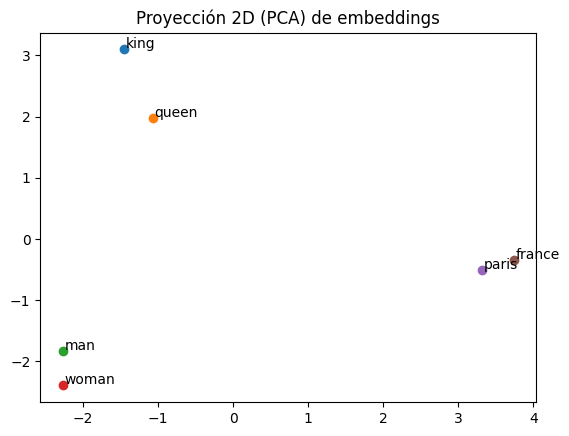

In [6]:
# Visualización 2D (PCA)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = ["king", "queen", "man", "woman", "paris", "france"]
words = [w for w in words if w in model]  # por si alguna no está
vectors = [model[w] for w in words]

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

for word, (x, y) in zip(words, coords):
    plt.scatter(x, y)
    plt.text(x+0.02, y+0.02, word)
plt.title("Proyección 2D (PCA) de embeddings")
plt.show()


In [7]:
# Analogías: king - man + woman ≈ queen
model.most_similar(positive=["king","woman"], negative=["man"], topn=5)


[('queen', 0.8523604273796082),
 ('throne', 0.7664334177970886),
 ('prince', 0.7592144012451172),
 ('daughter', 0.7473883628845215),
 ('elizabeth', 0.7460219860076904)]

### Reto corto 2
**Analogías:** prueba 3 analogías y comenta si funcionan.
- `paris - france + italy ≈ ?`
- `bigger - big + small ≈ ?`
- tu propia analogía

Adiciona una celda con resultados + 4–5 líneas de reflexión sobre **por qué** algunas analogías fallan.


In [ ]:
# ejercicio de Reto corto 2:
'''
Ejemplo1:
Dado un conjunto de palabras ‘similares’ en contexto, detectar las palabras fuera del contexto:
palabras = ["pera", "piña", "papaya", "carro"]

respuesta: "carro"

palabras = ["peach", "pineapple", "papaya", "car"]

respuesta: "car"

## cual es la sensibilidad al idioma?

'''

In [8]:
# 'Odd one out' (palabra fuera de contexto)
# Idea: la palabra más 'lejana' al centroide del grupo suele ser la intrusa.
import numpy as np

def odd_one_out(words, kv):
    ws=[w for w in words if w in kv]
    if len(ws)<3:
        return None, ws
    X=np.stack([kv[w] for w in ws])
    c=X.mean(axis=0)
    # distancia coseno al centroide
    Xn=X/np.linalg.norm(X,axis=1,keepdims=True)
    cn=c/np.linalg.norm(c)
    cos = Xn@cn
    idx=np.argmin(cos)  # menor coseno = más lejos
    return ws[idx], ws

odd_one_out(["peach","pineapple","papaya","car"], model)


('car', ['peach', 'pineapple', 'papaya', 'car'])

## 4) FastText (subwords) para OOV y morfología
FastText aprende embeddings **de n‑gramas de caracteres**.
Resultado: puede producir vector para palabras no vistas (OOV), y capta sufijos/prefijos.

En clase, para hacerlo rápido, entrenamos un **FastText mini** con pocas frases.


In [9]:
from gensim.models import FastText

sentences = [
    "el gato negro duerme en la casa".split(),
    "el perro negro corre en el jardin".split(),
    "la gata blanca duerme".split(),
    "los perros corren rapido".split(),
    "me gusta programar en python".split(),
    "programacion y programar son similares".split(),
]

ft = FastText(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,
    min_n=3, max_n=5,  # subwords
    epochs=50,
)

ft.wv.similarity("programar","programacion")


np.float32(0.5174846)

In [10]:
# OOV: palabra mal escrita o no vista
for w in ["programar", "programacion", "programación", "progrmar"]:
    try:
        v=ft.wv[w]
        print(w, "OK", "norm=", float(np.linalg.norm(v)))
    except KeyError:
        print(w, "OOV en vocab")

# Nota: en FastText, aunque una palabra no esté en el vocab,
# gensim puede generar vector si tiene subwords conocidos.


programar OK norm= 0.013699364848434925
programacion OK norm= 0.011523581109941006
programación OK norm= 0.012715519405901432
progrmar OK norm= 0.017507068812847137


### Reto corto 3
1. Agrega 8–10 oraciones nuevas sobre un dominio (p.e. ciclismo, bases de datos, cine).
2. Entrena de nuevo `ft` (sube `epochs` si hace falta).
3. Demuestra un caso donde FastText ayude con variaciones morfológicas u OOV:
   - singular/plural, masculino/femenino, sufijos (`-ción`, `-mente`) o un typo.

Adiciona 1 celda con 3 similitudes (coseno) + 3–4 líneas de interpretación.


In [11]:
# Mini-proyecto: buscador semántico de sinónimos locales
# Dado un término, devuelve las K palabras más cercanas según embeddings.

def semantic_neighbors(query, kv, topn=8):
    if query not in kv:
        return []
    return kv.most_similar(query, topn=topn)

semantic_neighbors("python", model, topn=10)


[('reticulated', 0.6916365623474121),
 ('spamalot', 0.6635736227035522),
 ('php', 0.6414496898651123),
 ('owl', 0.6301496028900146),
 ('mouse', 0.6275478601455688),
 ('reticulatus', 0.6274471282958984),
 ('perl', 0.6267575025558472),
 ('monkey', 0.6207211017608643),
 ('monty', 0.60793536901474),
 ('scripting', 0.6041731834411621)]

## 5) Minireto final — Mini-RAG con embeddings
Este es el puente directo al Momento 3 (RAG) de la Sesión 5 y al proyecto final: usamos los mismos embeddings de esta clase para **recuperar** el documento más relevante ante una pregunta, y citamos la fuente.


In [12]:
# === Mini-RAG: 4-5 documentos + búsqueda por similitud con embeddings ===
import numpy as np

documentos = {
    "doc1": "python es un lenguaje de programacion interpretado y de proposito general",
    "doc2": "machine learning es un campo de la inteligencia artificial que aprende de datos",
    "doc3": "paris es la capital de francia y una ciudad conocida por el arte",
    "doc4": "un gato es un animal domestico que suele dormir muchas horas al dia",
    "doc5": "la regresion logistica es un modelo clasico de clasificacion en machine learning",
}

def doc_embedding(texto, kv):
    """Promedio de los vectores de palabra como embedding del documento (baseline simple)."""
    vecs = [kv[w] for w in texto.split() if w in kv]
    if not vecs:
        return None
    return np.mean(vecs, axis=0)

doc_vecs = {doc_id: doc_embedding(texto, model) for doc_id, texto in documentos.items()}
doc_vecs = {k: v for k, v in doc_vecs.items() if v is not None}
print("Documentos indexados:", list(doc_vecs.keys()))


Documentos indexados: ['doc1', 'doc2', 'doc3', 'doc4', 'doc5']


In [13]:
# === Recuperación: dado un query, devolver el documento mas cercano (coseno) ===
def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

def retrieve(query, doc_vecs, kv, top_k=1):
    qv = doc_embedding(query, kv)
    if qv is None:
        return []
    scores = [(doc_id, cosine(qv, v)) for doc_id, v in doc_vecs.items()]
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

preguntas = [
    "que lenguaje se usa para programar",
    "cual es la capital de francia",
    "que modelo se usa para clasificar en machine learning",
]

for q in preguntas:
    resultado = retrieve(q, doc_vecs, model, top_k=2)
    print(f"\nPregunta: {q}")
    for doc_id, score in resultado:
        print(f"  {doc_id}  (similitud={score:.3f})  ->  \"{documentos[doc_id]}\"")



Pregunta: que lenguaje se usa para programar
  doc4  (similitud=0.824)  ->  "un gato es un animal domestico que suele dormir muchas horas al dia"
  doc2  (similitud=0.813)  ->  "machine learning es un campo de la inteligencia artificial que aprende de datos"

Pregunta: cual es la capital de francia
  doc3  (similitud=0.965)  ->  "paris es la capital de francia y una ciudad conocida por el arte"
  doc5  (similitud=0.894)  ->  "la regresion logistica es un modelo clasico de clasificacion en machine learning"

Pregunta: que modelo se usa para clasificar en machine learning
  doc5  (similitud=0.886)  ->  "la regresion logistica es un modelo clasico de clasificacion en machine learning"
  doc2  (similitud=0.863)  ->  "machine learning es un campo de la inteligencia artificial que aprende de datos"


### Minireto
1. Agrega 1-2 documentos propios (de tu dominio de interés) al diccionario `documentos`.
2. Escribe una pregunta cuya respuesta correcta dependa de tu documento nuevo, y verifica que `retrieve` lo recupere en el top-1.
3. En 3-4 líneas: ¿en qué casos el documento recuperado NO fue el esperado? ¿por qué crees que falló — el embedding, el promedio de palabras, o el propio documento?
4. Este mismo patrón (texto → embedding → búsqueda por similitud) es exactamente lo que usaremos en la Sesión 5 (RAG) y en el proyecto final, solo que allí el embedding vendrá de un modelo moderno (no del promedio de Word2Vec/GloVe) y habrá un LLM generando la respuesta final a partir del documento recuperado.


# Actividad Extraclase

## clustering con representación de embeddings y modelos clásicos no supervisados de ML

In [14]:
# descargar y descomprimir modelo fasttext con corpus en español
# 1.3 GB
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz

# 4.5 GB
!gunzip cc.es.300.vec.gz

--2026-08-14 18:04:05--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.es.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.118, 3.171.22.13, 3.171.22.68, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1285580896 (1.2G) [binary/octet-stream]
Saving to: ‘cc.es.300.vec.gz’

cc.es.300.vec.gz    100%[===================>]   1.20G  9.33MB/s    in 5m 30s  

2026-08-14 18:09:35 (3.72 MB/s) - ‘cc.es.300.vec.gz’ saved [1285580896/1285580896]



In [ ]:
# cargar el modelo desde el archivo descargado previamente
import gensim

# Cargar modelo FastText para español (debe estar descargado)
model = gensim.models.KeyedVectors.load_word2vec_format("cc.es.300.vec", binary=False)


In [16]:
palabras = [
    # objetos de casa
    "mueble", "nevera", "lavadora", "silla", "sofa", "tv",
    # colores
    "rojo", "amarillo", "verde", "azul", "gris", "negro",
    # Vehículos
    "auto", "camión", "moto", "bicicleta", "avión", "barco"
]

In [17]:
# verificar que las palabras si estén en el corpus del modelo, filtrar las que no están
X = [model[word] for word in palabras if word in model]
palabras_filtradas = [word for word in palabras if word in model]
print(palabras_filtradas)

['mueble', 'nevera', 'lavadora', 'silla', 'sofa', 'tv', 'rojo', 'amarillo', 'verde', 'azul', 'gris', 'negro', 'auto', 'camión', 'moto', 'bicicleta', 'avión', 'barco']


In [18]:
# ejecutar un modelo clásico de kmeans con 3 grupos
from sklearn.cluster import KMeans

k = 3  # número esperado de grupos
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)


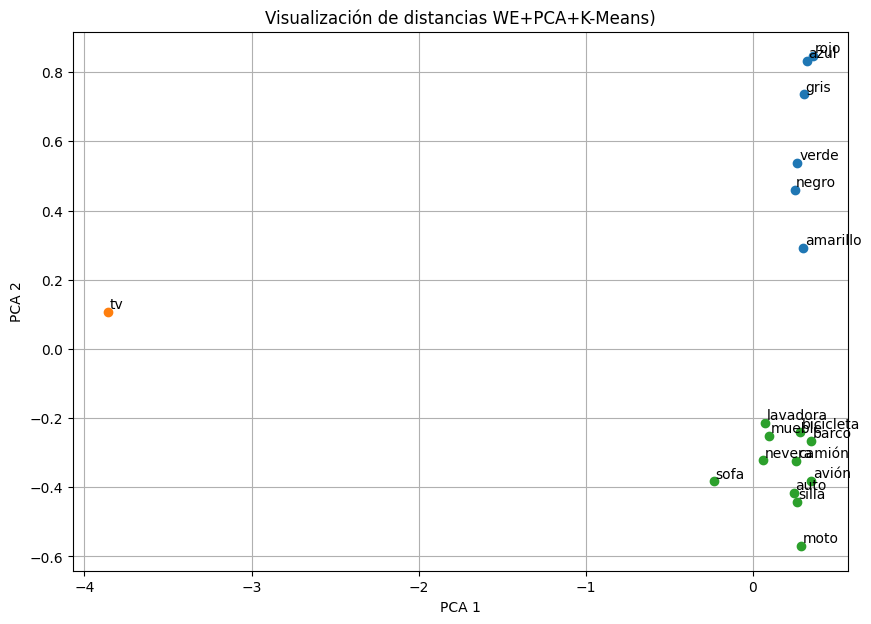

In [19]:
# visualizar en 2D grupos
# se utiliza PCA para poder proyectar en un espacio 2D vectores densos y conservar las relaciones de distancia
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducción de dimensión
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# Visualización
plt.figure(figsize=(10, 7))
for i, word in enumerate(palabras_filtradas):
    plt.scatter(coords[i, 0], coords[i, 1], c=f"C{labels[i]}")
    plt.text(coords[i, 0] + 0.01, coords[i, 1] + 0.01, word)
plt.title("Visualización de distancias WE+PCA+K-Means)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

In [ ]:
# analice los resultados y plantee otro dataset de palabras que SI permita tener 3 grupos bien identificados
